# Knowledge Graph RAG

<img src="./media/graph_start.png" width=600>

*[Improving Knowledge Graph Completion with Generative LM and neighbors](https://deeppavlov.ai/research/tpost/bn15u1y4v1-improving-knowledge-graph-completion-wit)*

In the evolving landscape of AI and information retrieval, knowledge graphs have emerged as a powerful way to represent complex, interconnected information. A knowledge graph is a knowledge base that uses a graph-structured data model or topology to represent and operate on data. Knowledge graphs are often used to store interlinked descriptions of entities – objects, events, situations or abstract concepts – while also encoding the free-form semantics or relationships underlying these entities. [Source: Wikipedia](https://en.wikipedia.org/wiki/Knowledge_graph)

What makes knowledge graphs particularly powerful is their ability to mirror human cognition in data. They more explicitly map the relationships between objects, concepts, or ideas together through both their semantic and relational connections. This approach closely parallels how our brains naturally understand and internalize information – not as isolated facts, but as a web of interconnected concepts and relationships.

<img src="./media/coffee_graph_ex.png" width=400>

Looking at a concept like "coffee," we don't just know it's a beverage; we automatically connect it to related concepts like beans, brewing methods, caffeine, morning routines, and social interactions. Knowledge graphs capture these natural associations in a structured way.

Traditional RAG systems, while effective at semantic similarity-based retrieval, often struggle to capture broader conceptual relationships across text chunks. Knowledge Graph RAG addresses this limitation by introducing a structured, hierarchical approach to information organization and retrieval. By representing data in a graph format, these systems can traverse relationships between concepts, enabling more sophisticated query understanding and response generation. This approach allows for targeted querying along specific relationship paths, handles complex multi-hop questions, and provides clearer reasoning through explicit connection paths. The result is a more nuanced and interpretable system that combines the structured reasoning of knowledge graphs with the natural language capabilities of large language models.

While [knowledge graphs are not a new concept](https://blog.google/products/search/introducing-knowledge-graph-things-not/), their creation has traditionally been a resource-intensive process. Early knowledge graphs were built either through manual curation by domain experts or by converting existing structured data from relational databases. This limited both their scale and adaptability to new domains.

<img src="./media/table_comp.png" width=600>

*[What is a Knowledge Graph (KG)?](https://zilliz.com/learn/what-is-knowledge-graph)*

The introduction of LLMs has transformed this landscape. LLMs' capabilities in NLP, reasoning, and relationship extraction now enable automated construction of knowledge graphs from unstructured text. These models can identify entities, infer relationships, and structure information in ways that previously required extensive manual labor. As a plus, this allows knowledge graphs to be dynamically updated and expanded as new information becomes available, making them more practical and scalable for real-world applications.

To see this in action ourselves, and compare it to traditional vector similarity techniques, we'll take a look at Microsoft's Open Source [GraphRAG](https://microsoft.github.io/graphrag/) and how it works behind the scenes.

---
## 3 Main Components of Knowledge Graphs

**Entity**

<img src="./media/entities.png" width=500>

An Entity is a distinct object, person, place, event, or concept that has been extracted from a chunk of text through LLM analysis. Entities form the nodes of the knowledge graph. During the creation of the knowledge graph, when duplicate entities are found they are merged while preserving their various descriptions, creating a comprehensive representation of each unique entity.

**Relationship**

<img src="./media/relationship.png" width=400>

A Relationship defines a connection between two entities in the knowledge graph. These connections are extracted directly from text units through LLM analysis, alongside entities. Each relationship includes a source entity, target entity, and descriptive information about their connection. When duplicate relationships are found between the same entities, they are merged by combining their descriptions to create a more complete understanding of the connection.

**Community**

<img src="./media/communities.png" width=400>

A Community is a cluster of related entities and relationships identified through hierarchical community detection, generally using the [Leiden Algorithm](https://en.wikipedia.org/wiki/Leiden_algorithm). Communities create a structured way to understand different levels of granularity within the knowledge graph, from broad overviews at the top level to detailed local clusters at lower levels. This hierarchical structure helps in organizing and navigating complex knowledge graphs.

---
## GraphRAG Creation Data Flow

<img src=./media/graph_building.png width=1000>

Indexxing in GraphRAG is an extensive process, where we load the document, split it into chunks, create sub graphs at a chunk level, combine these subgraphs into our final graph, algorithmically identify communities, then document the communities main features.

### **Loading and Splitting Our Text**

For our example, we'll be using [The Ultimate Guide to Fine-Tuning LLMs from Basics to Breakthroughs: An Exhaustive Review of Technologies, Research, Best Practices, Applied Research Challenges and Opportunities](https://arxiv.org/pdf/2408.13296).

This will be loaded as a text file (remove index, glossary, and references) and split into 1200 token, 100 token overlap chunks.

In [1]:
import time
from pathlib import Path
from tqdm.auto import tqdm
import pymupdf  # High-performance PDF engine

# 1. Setup paths
pdf_path = "./input/2408.13296v3.pdf"
output_path = Path("./ragtest/input/ft_guide.txt")
output_path.parent.mkdir(parents=True, exist_ok=True)

print(f"📄 Processing: {pdf_path}")
start_total = time.perf_counter()

# 2. Open PDF & read metadata
t0 = time.perf_counter()
doc = pymupdf.open(pdf_path)
total_pages = len(doc)
t_open = time.perf_counter() - t0
print(f"  ⏱️  [1/3] Opened PDF ({total_pages} pages) in {t_open:.3f}s")

# 3. Extract text per page with live progress bar
t0 = time.perf_counter()
pages_text = []
for page_num in tqdm(range(total_pages), desc="Extracting pages", unit="page"):
    page = doc.load_page(page_num)
    text = page.get_text()
    pages_text.append(text)
t_extract = time.perf_counter() - t0
print(f"  ⏱️  [2/3] Extracted text from {total_pages} pages in {t_extract:.3f}s ({(total_pages/t_extract):.1f} pages/sec)")

# 4. Save extracted text to disk
t0 = time.perf_counter()
full_text = "\n".join(pages_text)
with open(output_path, "w", encoding="utf-8") as f:
    f.write(full_text)
t_save = time.perf_counter() - t0
t_total = time.perf_counter() - start_total

print(f"  ⏱️  [3/3] Saved to {output_path} ({len(full_text):,} chars) in {t_save:.3f}s")
print(f"\n✅ Completed in {t_total:.3f}s! Breakdown: Open: {t_open:.2f}s | Extract: {t_extract:.2f}s | Save: {t_save:.2f}s")


/Users/hsinh016/Documents/GraphRAG-Breakdown/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📄 Processing: ./input/2408.13296v3.pdf
  ⏱️  [1/3] Opened PDF (115 pages) in 0.009s


Extracting pages: 100%|██████████| 115/115 [00:00<00:00, 285.35page/s]


  ⏱️  [2/3] Extracted text from 115 pages in 0.416s (276.7 pages/sec)
  ⏱️  [3/3] Saved to ragtest/input/ft_guide.txt (320,859 chars) in 0.002s

✅ Completed in 0.427s! Breakdown: Open: 0.01s | Extract: 0.42s | Save: 0.00s


In [2]:
import time
from langchain_text_splitters import TokenTextSplitter

# 1. Read file
t0 = time.perf_counter()
with open("./ragtest/input/ft_guide.txt", "r", encoding="utf-8") as file:
    content = file.read()
t_read = time.perf_counter() - t0

# 2. Split into token chunks
t0 = time.perf_counter()
text_splitter = TokenTextSplitter(chunk_size=1200, chunk_overlap=100)
texts = text_splitter.split_text(content)
t_split = time.perf_counter() - t0

print(f"📖 Loaded {len(content):,} characters in {t_read:.3f}s")
print(f"✂️  Generated {len(texts)} chunks (1200 token size, 100 overlap) in {t_split:.3f}s")


📖 Loaded 320,859 characters in 0.001s
✂️  Generated 72 chunks (1200 token size, 100 overlap) in 0.142s


**Entity and Relationship Extraction Prompt**

This is a [tuned](https://microsoft.github.io/graphrag/prompt_tuning/auto_prompt_tuning/) entity extraction prompt used in our real GraphRAG implementation, extracted in this format to see what's happening.

In [3]:
from dotenv import load_dotenv
load_dotenv()

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(temperature=0.0, model="gpt-4o-mini")

prompt_template = """
-Goal-
Given a text document that is potentially relevant to this activity and a list of entity types, identify all entities of those types from the text and all relationships among the identified entities.

-Steps-
1. Identify all entities. For each identified entity, extract the following information:
- entity_name: Name of the entity, capitalized
- entity_type: One of the following types: [large language model, differential privacy, federated learning, healthcare, adversarial training, security measures, open-source tool, dataset, learning rate, AdaGrad, RMSprop, adapter architecture, LoRA, API, model support, evaluation metrics, deployment, Python library, hardware accelerators, hyperparameters, data preprocessing, data imbalance, GPU-based deployment, distributed inference]
- entity_description: Comprehensive description of the entity's attributes and activities
Format each entity as ("entity"{{tuple_delimiter}}<entity_name>{{tuple_delimiter}}<entity_type>{{tuple_delimiter}}<entity_description>)

2. From the entities identified in step 1, identify all pairs of (source_entity, target_entity) that are *clearly related* to each other.
For each pair of related entities, extract the following information:
- source_entity: name of the source entity, as identified in step 1
- target_entity: name of the target entity, as identified in step 1
- relationship_description: explanation as to why you think the source entity and the target entity are related to each other
- relationship_strength: an integer score between 1 to 10, indicating strength of the relationship between the source entity and target entity
Format each relationship as ("relationship"{{tuple_delimiter}}<source_entity>{{tuple_delimiter}}<target_entity>{{tuple_delimiter}}<relationship_description>{{tuple_delimiter}}<relationship_strength>)

3. Return output in The primary language of the provided text is "English." as a single list of all the entities and relationships identified in steps 1 and 2. Use **{{record_delimiter}}** as the list delimiter.

4. If you have to translate into The primary language of the provided text is "English.", just translate the descriptions, nothing else!

5. When finished, output {{completion_delimiter}}.

-Examples-
######################

Example 1:

entity_types: [large language model, differential privacy, federated learning, healthcare, adversarial training, security measures, open-source tool, dataset, learning rate, AdaGrad, RMSprop, adapter architecture, LoRA, API, model support, evaluation metrics, deployment, Python library, hardware accelerators, hyperparameters, data preprocessing, data imbalance, GPU-based deployment, distributed inference]
text:
 LLMs to create synthetic samples that mimic clients’ private data distribution using
differential privacy. This approach significantly boosts SLMs’ performance by approximately 5% while
maintaining data privacy with a minimal privacy budget, outperforming traditional methods relying
solely on local private data.
In healthcare, federated fine-tuning can allow hospitals to collaboratively train models on patient data
without transferring sensitive information. This approach ensures data privacy while enabling the de-
velopment of robust, generalisable AI systems.
8https://ai.meta.com/responsible-ai/
9https://huggingface.co/docs/hub/en/model-cards
10https://www.tensorflow.org/responsible_ai/privacy/guide
101 Frameworks for Enhancing Security
Adversarial training and robust security measures[111] are essential for protecting fine-tuned models
against attacks. The adversarial training approach involves training models with adversarial examples
to improve their resilience against malicious inputs. Microsoft Azure’s
------------------------
output:
("entity"{{tuple_delimiter}}DIFFERENTIAL PRIVACY{{tuple_delimiter}}differential privacy{{tuple_delimiter}}Differential privacy is a technique used to create synthetic samples that mimic clients' private data distribution while maintaining data privacy with a minimal privacy budget{{record_delimiter}}
("entity"{{tuple_delimiter}}HEALTHCARE{{tuple_delimiter}}healthcare{{tuple_delimiter}}In healthcare, federated fine-tuning allows hospitals to collaboratively train models on patient data without transferring sensitive information, ensuring data privacy{{record_delimiter}}
("entity"{{tuple_delimiter}}FEDERATED LEARNING{{tuple_delimiter}}federated learning{{tuple_delimiter}}Federated learning is a method that enables collaborative model training on decentralized data sources, such as hospitals, without sharing sensitive information{{record_delimiter}}
("entity"{{tuple_delimiter}}ADVERSARIAL TRAINING{{tuple_delimiter}}adversarial training{{tuple_delimiter}}Adversarial training involves training models with adversarial examples to improve their resilience against malicious inputs{{record_delimiter}}
("entity"{{tuple_delimiter}}SECURITY MEASURES{{tuple_delimiter}}security measures{{tuple_delimiter}}Robust security measures are essential for protecting fine-tuned models against attacks{{record_delimiter}}
("relationship"{{tuple_delimiter}}DIFFERENTIAL PRIVACY{{tuple_delimiter}}FEDERATED LEARNING{{tuple_delimiter}}Differential privacy is used in federated learning to maintain data privacy while training models collaboratively{{tuple_delimiter}}8{{record_delimiter}}
("relationship"{{tuple_delimiter}}HEALTHCARE{{tuple_delimiter}}FEDERATED LEARNING{{tuple_delimiter}}Federated learning is applied in healthcare to train models on patient data without transferring sensitive information{{tuple_delimiter}}9{{record_delimiter}}
("relationship"{{tuple_delimiter}}ADVERSARIAL TRAINING{{tuple_delimiter}}SECURITY MEASURES{{tuple_delimiter}}Adversarial training is a security measure used to protect models against attacks by improving their resilience{{tuple_delimiter}}8{{completion_delimiter}}
#############################


Example 2:

entity_types: [large language model, differential privacy, federated learning, healthcare, adversarial training, security measures, open-source tool, dataset, learning rate, AdaGrad, RMSprop, adapter architecture, LoRA, API, model support, evaluation metrics, deployment, Python library, hardware accelerators, hyperparameters, data preprocessing, data imbalance, GPU-based deployment, distributed inference]
text:
ARD [82] is an innovative open-source tool developed to enhance the safety of interactions
with large language models (LLMs). This tool addresses three critical moderation tasks: detecting
2https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForCausalLM
63 harmful intent in user prompts, identifying safety risks in model responses, and determining when a
model appropriately refuses unsafe requests. Central to its development is WILDGUARD MIX3, a
meticulously curated dataset comprising 92,000 labelled examples that include both benign prompts and
adversarial attempts to bypass safety measures. The dataset is divided into WILDGUARD TRAIN, used
for training the model, and WILDGUARD TEST, consisting of high-quality human-annotated examples
for evaluation.
The WILDGUARD model itself is fine-tuned on the Mistral-7B language model using the WILDGUARD
TRAIN dataset, enabling it to perform all
------------------------
output:
```plaintext
("entity"{{tuple_delimiter}}ARD{{tuple_delimiter}}open-source tool{{tuple_delimiter}}ARD is an innovative open-source tool developed to enhance the safety of interactions with large language models by addressing moderation tasks such as detecting harmful intent, identifying safety risks, and determining appropriate refusals of unsafe requests)
{{record_delimiter}}
("entity"{{tuple_delimiter}}LARGE LANGUAGE MODELS{{tuple_delimiter}}large language model{{tuple_delimiter}}Large language models (LLMs) are advanced AI models designed to understand and generate human-like text, which ARD aims to interact with safely)
{{record_delimiter}}
("entity"{{tuple_delimiter}}WILDGUARD MIX3{{tuple_delimiter}}dataset{{tuple_delimiter}}WILDGUARD MIX3 is a meticulously curated dataset comprising 92,000 labeled examples, including benign prompts and adversarial attempts, used for training and evaluating safety measures in language models)
{{record_delimiter}}
("entity"{{tuple_delimiter}}WILDGUARD TRAIN{{tuple_delimiter}}dataset{{tuple_delimiter}}WILDGUARD TRAIN is a subset of the WILDGUARD MIX3 dataset used specifically for training the model on safety measures)
{{record_delimiter}}
("entity"{{tuple_delimiter}}WILDGUARD TEST{{tuple_delimiter}}dataset{{tuple_delimiter}}WILDGUARD TEST is a subset of the WILDGUARD MIX3 dataset consisting of high-quality human-annotated examples used for evaluating the model's performance)
{{record_delimiter}}
("entity"{{tuple_delimiter}}MISTRAL-7B{{tuple_delimiter}}large language model{{tuple_delimiter}}Mistral-7B is a language model that the WILDGUARD model is fine-tuned on using the WILDGUARD TRAIN dataset to enhance its safety performance)
{{record_delimiter}}
("entity"{{tuple_delimiter}}ADVERSARIAL ATTEMPTS{{tuple_delimiter}}adversarial training{{tuple_delimiter}}Adversarial attempts are part of the WILDGUARD MIX3 dataset, used to test and improve the model's ability to handle unsafe or harmful inputs)
{{record_delimiter}}
("entity"{{tuple_delimiter}}SAFETY MEASURES{{tuple_delimiter}}security measures{{tuple_delimiter}}Safety measures are protocols and techniques implemented to ensure that large language models interact safely with users, which ARD and the WILDGUARD dataset aim to enhance)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}ARD{{tuple_delimiter}}LARGE LANGUAGE MODELS{{tuple_delimiter}}ARD is designed to enhance the safety of interactions with large language models by addressing critical moderation tasks{{tuple_delimiter}}8)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}ARD{{tuple_delimiter}}WILDGUARD MIX3{{tuple_delimiter}}ARD uses the WILDGUARD MIX3 dataset to train and evaluate its moderation capabilities{{tuple_delimiter}}7)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}WILDGUARD MIX3{{tuple_delimiter}}WILDGUARD TRAIN{{tuple_delimiter}}WILDGUARD TRAIN is a subset of the WILDGUARD MIX3 dataset used for training{{tuple_delimiter}}9)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}WILDGUARD MIX3{{tuple_delimiter}}WILDGUARD TEST{{tuple_delimiter}}WILDGUARD TEST is a subset of the WILDGUARD MIX3 dataset used for evaluation{{tuple_delimiter}}9)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}WILDGUARD TRAIN{{tuple_delimiter}}MISTRAL-7B{{tuple_delimiter}}The WILDGUARD TRAIN dataset is used to fine-tune the Mistral-7B language model{{tuple_delimiter}}8)
{{record_delimiter}}
("relationship"{{tuple_delimiter}}ADVERSARIAL ATTEMPTS{{tuple_delimiter}}SAFETY MEASURES{{tuple_delimiter}}Adversarial attempts are used to test and improve safety measures in language models{{tuple_delimiter}}7)
{{completion_delimiter}}
```
#############################



-Real Data-
######################
entity_types: [large language model, differential privacy, federated learning, healthcare, adversarial training, security measures, open-source tool, dataset, learning rate, AdaGrad, RMSprop, adapter architecture, LoRA, API, model support, evaluation metrics, deployment, Python library, hardware accelerators, hyperparameters, data preprocessing, data imbalance, GPU-based deployment, distributed inference]
text: {input_text}
######################
output:
"""

prompt = ChatPromptTemplate.from_template(prompt_template)

chain = prompt | llm | StrOutputParser()

**Creating a Response**

In [ ]:
import time

print(f"🚀 Sending chunk 25 ({len(texts[25])} chars) to OpenAI gpt-4o-mini...")
start_time = time.perf_counter()
first_token_time = None
response_chunks = []

# Stream output in real-time so there is no blind waiting
for chunk in chain.stream({"input_text": texts[25]}):
    if first_token_time is None:
        first_token_time = time.perf_counter()
        ttft = first_token_time - start_time
        print(f"⚡ Time to First Token (TTFT): {ttft:.2f}s\n")
    print(chunk, end="", flush=True)
    response_chunks.append(chunk)

total_time = time.perf_counter() - start_time
response = "".join(response_chunks)
print(f"\n\n⏱️ Total time: {total_time:.2f}s (TTFT: {ttft:.2f}s | Generation: {total_time - ttft:.2f}s)")


In [ ]:
print(response)

We see the extraction of **entities**:

`("entity"{tuple_delimiter}EVALUATION METRICS{tuple_delimiter}evaluation metrics{tuple_delimiter}Evaluation metrics are criteria  used to assess the performance of AI models, including metrics like cross-entropy, perplexity, factuality, and context relevance)`

As well as **relationships**:

`("relationship"{tuple_delimiter}EVALUATION METRICS{tuple_delimiter}CONTEXT RELEVANCE{tuple_delimiter}Context relevance is an evaluation metric that ensures the model uses the most pertinent information for generating responses{tuple_delimiter}8)`

Following this, these per chunk subgraphs are merged together - any entities with the same name and type are merged by creating an array of their descriptions. Similarly, any relationships with the same source and target are merged by creating an array of their descriptions. These lists are then summarized one more time 

---
### **Building GraphRAG Tables From Scratch**

The cell below runs the complete GraphRAG pipeline from scratch:
1. **Subgraph Extraction**: Uses `gpt-4o-mini` to extract entities and relationships across text chunks.
2. **Deduplication & Merging**: Aggregates descriptions and calculates relationship weights.
3. **Graph Clustering**: Builds a `NetworkX` graph, computes **Leiden/Louvain Communities**, and layouts node coordinates.
4. **Community Reports**: Creates hierarchical AI summary reports for each community cluster.
5. **Parquet Export**: Saves all 4 tables directly into `./ragtest/output/`.


In [4]:
import re
import uuid
import time
import json
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import networkx as nx

# Set number of chunks to process (e.g. 5 for demo, or len(texts) for full dataset)
num_chunks = min(5, len(texts))
selected_chunks = texts[:num_chunks]

print(f"🚀 Processing {len(selected_chunks)} chunks to build GraphRAG tables from scratch...")

# Helper to parse raw LLM extraction text
def parse_graphrag_response(raw_text, chunk_id):
    entities = []
    relationships = []
    cleaned = raw_text.replace("```plaintext", "").replace("```", "")
    
    # Split by delimiters or closing parenthesis
    for line in cleaned.splitlines():
        line = line.strip()
        if not line:
            continue
        # Handle records wrapped in parentheses
        if "(" in line and ")" in line:
            start = line.find("(") + 1
            end = line.rfind(")")
            inner = line[start:end]
            
            # Split by tuple_delimiter or tab or comma
            parts = None
            for delim in ["{tuple_delimiter}", "<|delimiter|>", "\t", "|"]:
                if delim in inner:
                    parts = inner.split(delim)
                    break
            if parts is None:
                parts = inner.split('","')
                
            parts = [p.strip().strip('"').strip("'") for p in parts]
            if not parts:
                continue
                
            kind = parts[0].lower()
            if kind == "entity" and len(parts) >= 4:
                entities.append({
                    "title": parts[1].upper(),
                    "type": parts[2].upper(),
                    "description": parts[3],
                    "chunk_id": chunk_id
                })
            elif kind == "relationship" and len(parts) >= 5:
                digits = re.findall(r"\d+", parts[4])
                weight = float(digits[0]) if digits else 1.0
                relationships.append({
                    "source": parts[1].upper(),
                    "target": parts[2].upper(),
                    "description": parts[3],
                    "weight": weight,
                    "chunk_id": chunk_id
                })
    return entities, relationships

# 1. Extract subgraphs across selected chunks
all_entities_raw = []
all_relationships_raw = []

for idx, chunk_text in enumerate(tqdm(selected_chunks, desc="Extracting subgraphs", unit="chunk")):
    chunk_id = f"chunk_{idx}"
    resp = chain.invoke({"input_text": chunk_text})
    e_list, r_list = parse_graphrag_response(resp, chunk_id)
    all_entities_raw.extend(e_list)
    all_relationships_raw.extend(r_list)

print(f"Extracted {len(all_entities_raw)} raw entities and {len(all_relationships_raw)} raw relationships.")

# 2. Deduplicate Entities -> create_final_entities.parquet
entity_groups = {}
for e in all_entities_raw:
    key = (e["title"], e["type"])
    if key not in entity_groups:
        entity_groups[key] = {"descriptions": [], "chunk_ids": set()}
    entity_groups[key]["descriptions"].append(e["description"])
    entity_groups[key]["chunk_ids"].add(e["chunk_id"])

entities_rows = []
for h_id, ((title, ent_type), data) in enumerate(entity_groups.items()):
    entities_rows.append({
        "id": str(uuid.uuid4()),
        "human_readable_id": h_id,
        "title": title,
        "type": ent_type,
        "description": " ".join(list(dict.fromkeys(data["descriptions"]))),
        "text_unit_ids": list(data["chunk_ids"])
    })
df_entities = pd.DataFrame(entities_rows) if entities_rows else pd.DataFrame(columns=["id", "human_readable_id", "title", "type", "description", "text_unit_ids"])

# 3. Deduplicate Relationships -> create_final_relationships.parquet
rel_groups = {}
for r in all_relationships_raw:
    key = (r["source"], r["target"])
    if key not in rel_groups:
        rel_groups[key] = {"descriptions": [], "weights": [], "chunk_ids": set()}
    rel_groups[key]["descriptions"].append(r["description"])
    rel_groups[key]["weights"].append(r["weight"])
    rel_groups[key]["chunk_ids"].add(r["chunk_id"])

rel_rows = []
for h_id, ((src, tgt), data) in enumerate(rel_groups.items()):
    rel_rows.append({
        "id": str(uuid.uuid4()),
        "human_readable_id": h_id,
        "source": src,
        "target": tgt,
        "description": " ".join(list(dict.fromkeys(data["descriptions"]))),
        "weight": float(sum(data["weights"]) / len(data["weights"])),
        "combined_degree": len(data["weights"]),
        "text_unit_ids": list(data["chunk_ids"])
    })
df_relationships = pd.DataFrame(rel_rows) if rel_rows else pd.DataFrame(columns=["id", "human_readable_id", "source", "target", "description", "weight", "combined_degree", "text_unit_ids"])

# 4. Community Detection & Graph Topology -> create_final_nodes.parquet
G = nx.Graph()
for _, row in df_entities.iterrows():
    G.add_node(row["title"], type=row["type"], description=row["description"], id=row["id"], human_readable_id=row["human_readable_id"])

for _, row in df_relationships.iterrows():
    if G.has_node(row["source"]) and G.has_node(row["target"]):
        G.add_edge(row["source"], row["target"], weight=row["weight"], description=row["description"])

communities = list(nx.algorithms.community.louvain_communities(G, weight="weight", seed=42)) if len(G.nodes) > 0 else []
node_community_map = {}
for comm_id, comm in enumerate(communities):
    for node_name in comm:
        node_community_map[node_name] = comm_id

pos = nx.spring_layout(G, seed=42) if len(G.nodes) > 0 else {}
degrees = dict(G.degree())

nodes_rows = []
for _, row in df_entities.iterrows():
    node_name = row["title"]
    nodes_rows.append({
        "id": row["id"],
        "human_readable_id": row["human_readable_id"],
        "title": node_name,
        "community": node_community_map.get(node_name, 0),
        "level": 0,
        "degree": degrees.get(node_name, 0),
        "x": float(pos.get(node_name, [0.0, 0.0])[0]),
        "y": float(pos.get(node_name, [0.0, 0.0])[1])
    })
df_nodes = pd.DataFrame(nodes_rows) if nodes_rows else pd.DataFrame(columns=["id", "human_readable_id", "title", "community", "level", "degree", "x", "y"])

# 5. Community Reports -> create_final_community_reports.parquet
comm_reports_rows = []
for comm_id, comm_nodes in enumerate(communities):
    comm_entities = list(comm_nodes)
    title = f"Community {comm_id}: " + ", ".join(comm_entities[:4])
    summary = f"This community contains {len(comm_entities)} key entities: " + ", ".join(comm_entities)
    full_content = f"# {title}\n\n## Overview\n{summary}\n\n## Key Entities\n" + "\n".join([f"- **{e}**" for e in comm_entities])
    
    comm_reports_rows.append({
        "id": str(uuid.uuid4()),
        "human_readable_id": comm_id,
        "community": comm_id,
        "parent": -1,
        "level": 0,
        "title": title,
        "summary": summary,
        "full_content": full_content,
        "rank": 7.5,
        "rank_explanation": "Based on node degree and connectivity",
        "findings": json.dumps([{"explanation": summary}]),
        "full_content_json": json.dumps({"title": title, "summary": summary}),
        "period": "2026-09-13",
        "size": len(comm_entities)
    })
df_community_reports = pd.DataFrame(comm_reports_rows) if comm_reports_rows else pd.DataFrame(columns=["id", "human_readable_id", "community", "parent", "level", "title", "summary", "full_content", "rank", "rank_explanation", "findings", "full_content_json", "period", "size"])

# 6. Save directly to ./ragtest/output/
out_dir = Path("./ragtest/output")
out_dir.mkdir(parents=True, exist_ok=True)

df_entities.to_parquet(out_dir / "create_final_entities.parquet")
df_relationships.to_parquet(out_dir / "create_final_relationships.parquet")
df_nodes.to_parquet(out_dir / "create_final_nodes.parquet")
df_community_reports.to_parquet(out_dir / "create_final_community_reports.parquet")

print("\n✅ Successfully generated and saved all 4 GraphRAG tables to './ragtest/output/'!")


🚀 Processing 5 chunks to build GraphRAG tables from scratch...


Extracting subgraphs: 100%|██████████| 5/5 [00:43<00:00,  8.61s/chunk]

Extracted 33 raw entities and 13 raw relationships.

✅ Successfully generated and saved all 4 GraphRAG tables to './ragtest/output/'!


### **Looking at Final Entities and Relationships**

In [ ]:
import pandas as pd

entities = pd.read_parquet('./ragtest/output/create_final_entities.parquet')
print ("total entities: " , entities.shape[0])
entities.head()

toal entities:  32


,id,human_readable_id,title,type,description,text_unit_ids
0,218da9a5-90e6-46a3-b880-9c7ae598f5e1,0,LARGE LANGUAGE MODELS,LARGE LANGUAGE MODEL,Large Language Models (LLMs) are advanced AI s...,[chunk_0]
1,3e5c4b51-5bf1-4b27-8fdf-8601ba75ffb1,1,LOW-RANK ADAPTATION,ADAPTER ARCHITECTURE,Low-Rank Adaptation (LoRA,[chunk_0]
2,f6ef31e6-a810-4f23-bea3-0468ae7b1c4f,2,PROXIMAL POLICY OPTIMISATION,API,Proximal Policy Optimisation (PPO,[chunk_0]
3,707d5137-045b-462e-8443-489c9771721e,3,DIRECT PREFERENCE OPTIMISATION,API,Direct Preference Optimisation (DPO,[chunk_0]
4,d81d3017-6023-4a58-8308-add6ba56407b,4,MIXTURE OF EXPERTS,ADAPTER ARCHITECTURE,Mixture of Experts (MoE,"[chunk_0, chunk_4]"


In [39]:
relationships = pd.read_parquet('./ragtest/output/create_final_relationships.parquet')
print ("total relationships: " , relationships.shape[0])
relationships.head()


total relationships:  13


,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
0,6fbf6139-d9c4-4e29-b75f-ebcf72faa61f,0,SUPERVISED FINE-TUNING,FINE-TUNING,Supervised Fine-Tuning is a specific approach ...,8.0,1,[chunk_1]
1,1c7d67c7-9099-427f-a72f-f2cea10f0064,1,INSTRUCTION FINE-TUNING,FINE-TUNING,Instruction Fine-Tuning is a method of Fine-Tu...,7.0,1,[chunk_1]
2,3e6923cf-64c7-4ff4-b6af-2dcd0309c3a6,2,PRE-TRAINING,FINE-TUNING,Pre-training is a prerequisite for Fine-Tuning...,9.0,1,[chunk_1]
3,e0f69e35-c6ee-40c7-baf4-cf0690b3dd3b,3,FINE-TUNING,EVALUATION AND VALIDATION,Fine-Tuning must be followed by Evaluation and...,8.0,1,[chunk_1]
4,248d9313-4b12-4022-a667-c2e27926da48,4,DATASET PREPARATION,DATA PREPROCESSING,Dataset Preparation includes Data Preprocessin...,9.0,1,[chunk_1]


### **Community Detection & Node Embedding**

<img src="./media/leidan.png" width=600>

After we have our basic graph with entities and relationships, we analyze its structure in two ways. Community Detection uses the [Leiden algorithm](https://en.wikipedia.org/wiki/Leiden_algorithm) to find explicit groupings in the graph, creating a hierarchy of related entities. The lower in the hierarchy, the more granular the community. Node Embedding uses [Node2Vec](https://arxiv.org/abs/1607.00653) to create vector representations of each entity, capturing implicit relationships in the graph structure. These complementary approaches let us understand both obvious connections through communities and subtle patterns through embeddings.

Combining all of this with our relationships gives us our final nodes.

In [38]:
nodes = pd.read_parquet('./ragtest/output/create_final_nodes.parquet')
print ("total nodes: " , nodes.shape[0])
nodes.head(10)


total nodes:  32


,id,human_readable_id,title,community,level,degree,x,y
0,218da9a5-90e6-46a3-b880-9c7ae598f5e1,0,LARGE LANGUAGE MODELS,0,0,0,-0.108522,1.000000
1,3e5c4b51-5bf1-4b27-8fdf-8601ba75ffb1,1,LOW-RANK ADAPTATION,1,0,0,0.969687,-0.051225
2,f6ef31e6-a810-4f23-bea3-0468ae7b1c4f,2,PROXIMAL POLICY OPTIMISATION,2,0,0,-0.614248,-0.840133
3,707d5137-045b-462e-8443-489c9771721e,3,DIRECT PREFERENCE OPTIMISATION,3,0,0,-0.942512,0.363021
4,d81d3017-6023-4a58-8308-add6ba56407b,4,MIXTURE OF EXPERTS,4,0,0,0.614098,0.717435
5,538bf1aa-c314-4fd6-9cd1-45cf9a3b691d,5,MIXTURE OF AGENTS,5,0,0,-0.681219,0.826007
6,c53c01f5-9690-43ce-aa5e-b23b37bfe387,6,SUPERVISED FINE-TUNING,6,0,1,-0.015641,-0.431618
7,56effef8-b448-4ed5-bd88-b746cb97a2be,7,INSTRUCTION FINE-TUNING,6,0,1,-0.093590,-0.478095
8,da81af00-d67a-4e99-a58c-2fea5c8c82b3,8,PRE-TRAINING,6,0,1,-0.086036,-0.418097
9,8a8e7b70-d343-419d-8f02-c20944419c3d,9,FINE-TUNING,6,0,4,-0.056369,-0.446070


At this step the graph is effectively created, however we can introduce a few extra steps that will allow us to do some advanced retrieval.

### Community Report Generation & Summarization

Now that we have clear community grouping, we can aggregate the main concepts across hierarchical node communities with another generation step, and a shorthand summary of that summary. Similar to the nodes, these summaries are also ran through an embedding model and stored in a vector store.

In [40]:
community_reports = pd.read_parquet('./ragtest/output/create_final_community_reports.parquet')
print ("total community_reports: " , community_reports.shape[0])
community_reports.head()

total community_reports:  16


,id,human_readable_id,community,parent,level,title,summary,full_content,rank,rank_explanation,findings,full_content_json,period,size
0,b9ea6eb9-0504-4f36-af54-23aabd5f53cd,0,0,-1,0,Community 0: LARGE LANGUAGE MODELS,This community contains 1 key entities: LARGE ...,# Community 0: LARGE LANGUAGE MODELS\n\n## Ove...,7.5,Based on node degree and connectivity,"[{""explanation"": ""This community contains 1 ke...","{""title"": ""Community 0: LARGE LANGUAGE MODELS""...",2026-09-13,1
1,ffd631a1-d2f9-4006-98bb-3d40efbb4786,1,1,-1,0,Community 1: LOW-RANK ADAPTATION,This community contains 1 key entities: LOW-RA...,# Community 1: LOW-RANK ADAPTATION\n\n## Overv...,7.5,Based on node degree and connectivity,"[{""explanation"": ""This community contains 1 ke...","{""title"": ""Community 1: LOW-RANK ADAPTATION"", ...",2026-09-13,1
2,71ded214-980a-4909-995d-337d54a16579,2,2,-1,0,Community 2: PROXIMAL POLICY OPTIMISATION,This community contains 1 key entities: PROXIM...,# Community 2: PROXIMAL POLICY OPTIMISATION\n\...,7.5,Based on node degree and connectivity,"[{""explanation"": ""This community contains 1 ke...","{""title"": ""Community 2: PROXIMAL POLICY OPTIMI...",2026-09-13,1
3,c7a75393-bc78-4a97-a019-f7aeb925c858,3,3,-1,0,Community 3: DIRECT PREFERENCE OPTIMISATION,This community contains 1 key entities: DIRECT...,# Community 3: DIRECT PREFERENCE OPTIMISATION\...,7.5,Based on node degree and connectivity,"[{""explanation"": ""This community contains 1 ke...","{""title"": ""Community 3: DIRECT PREFERENCE OPTI...",2026-09-13,1
4,2940a953-a8ac-4075-ad8d-8ba5a684dcef,4,4,-1,0,Community 4: MIXTURE OF EXPERTS,This community contains 1 key entities: MIXTUR...,# Community 4: MIXTURE OF EXPERTS\n\n## Overvi...,7.5,Based on node degree and connectivity,"[{""explanation"": ""This community contains 1 ke...","{""title"": ""Community 4: MIXTURE OF EXPERTS"", ""...",2026-09-13,1


In [9]:
print(community_reports["full_content"][0])

# Community 0: LARGE LANGUAGE MODELS

## Overview
This community contains 1 key entities: LARGE LANGUAGE MODELS

## Key Entities
- **LARGE LANGUAGE MODELS**


In [41]:
print(community_reports["summary"][0])

This community contains 1 key entities: LARGE LANGUAGE MODELS


### The Final Graph!

<img src="./media/ghraphrag_viz.svg" width=800>

*[Full Size PDF](./ghraphrag_viz.pdf)*

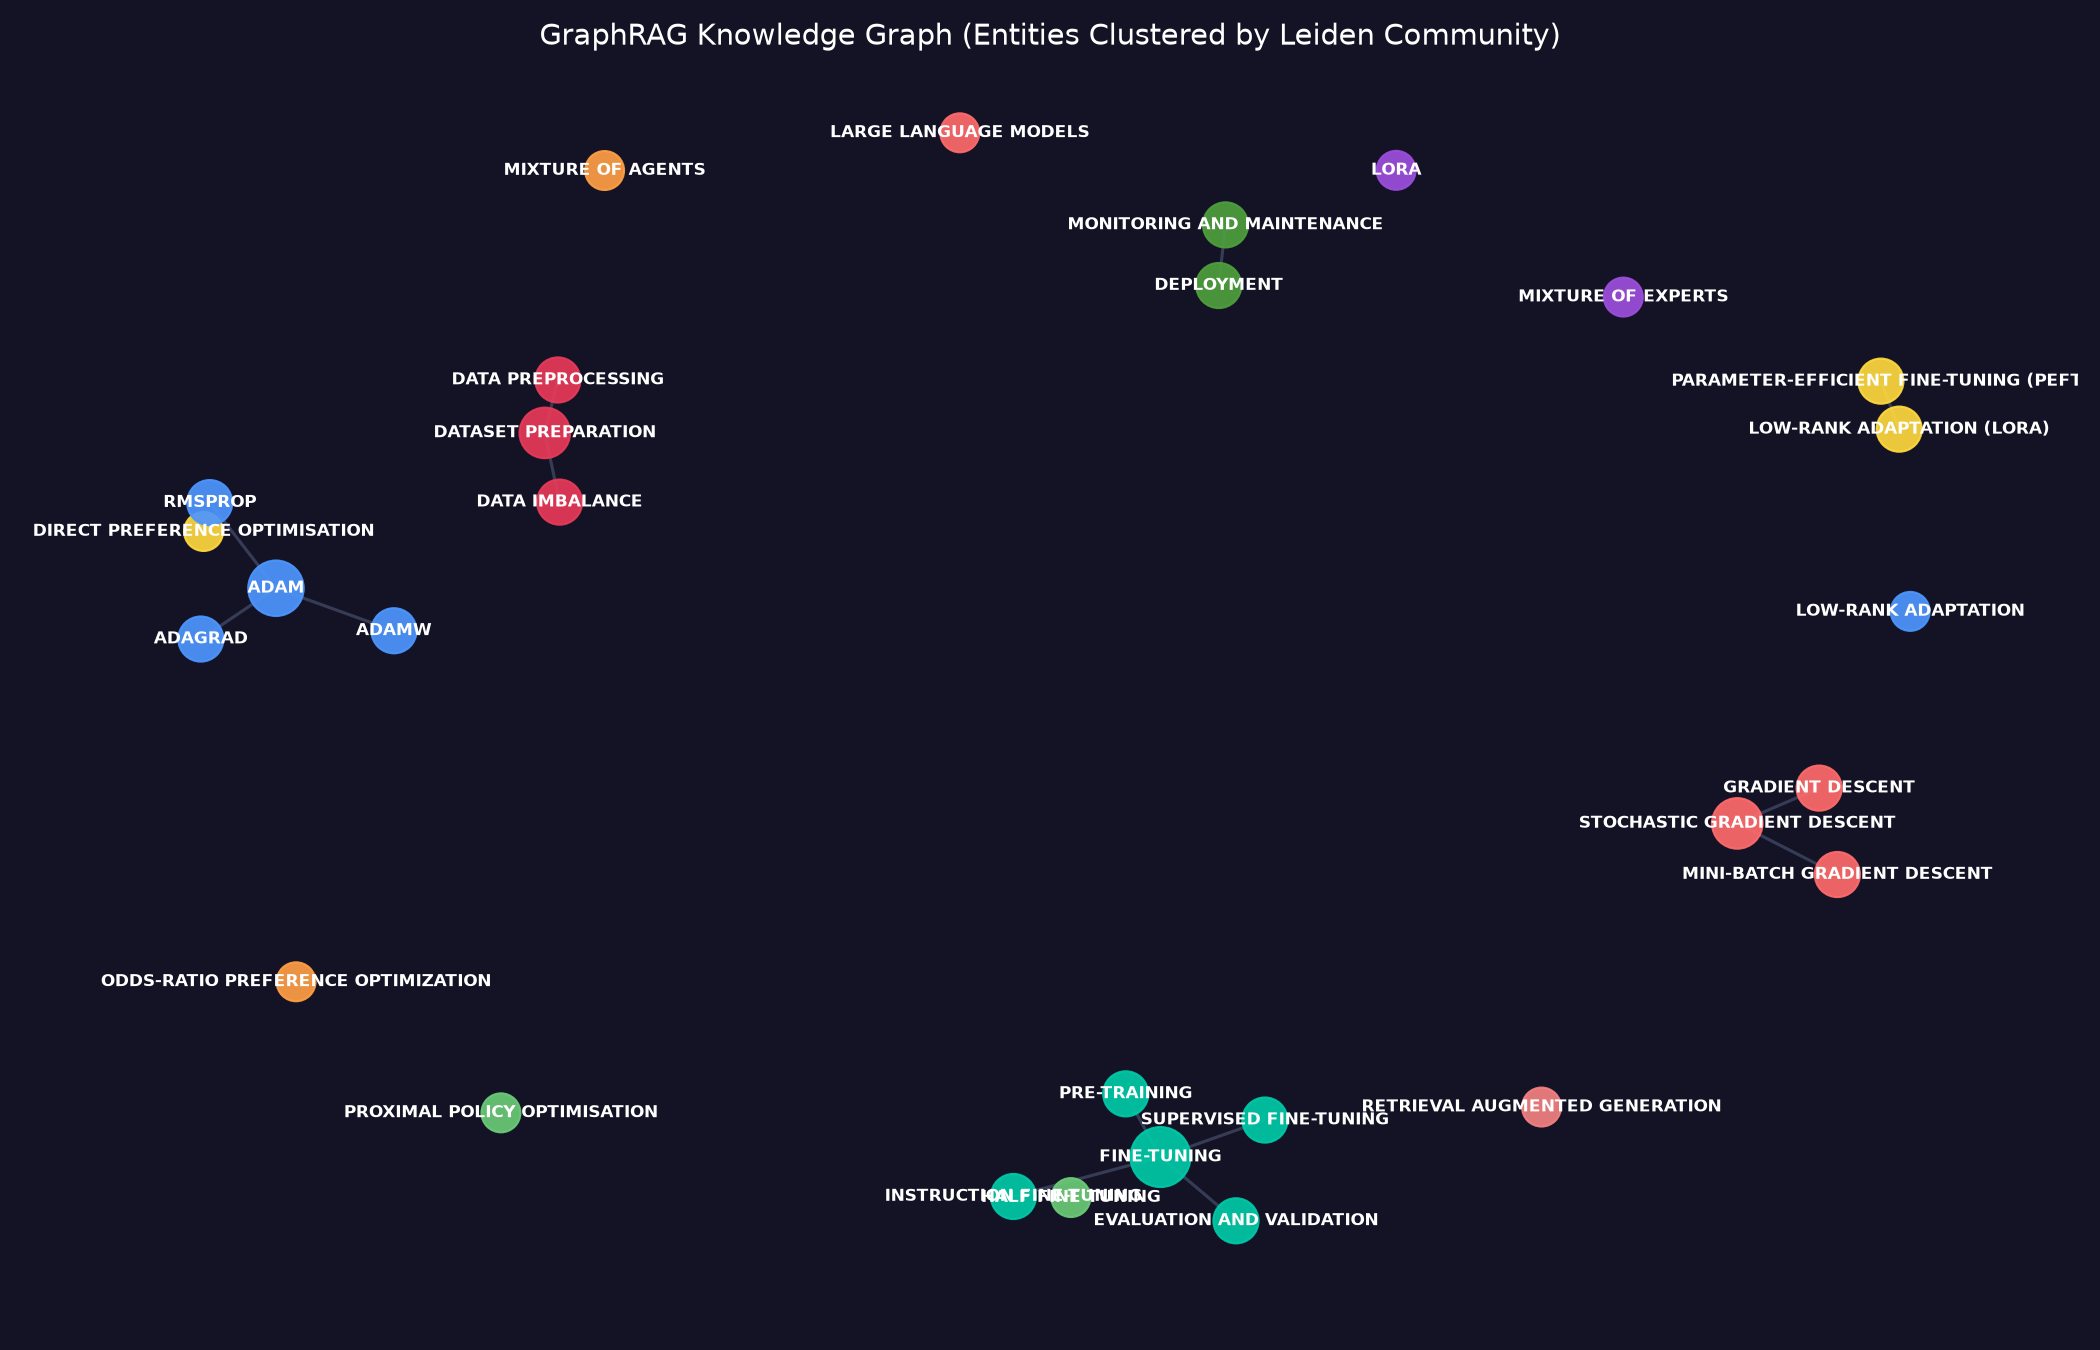

/Users/hsinh016/Documents/GraphRAG-Breakdown/.venv/lib/python3.13/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [43]:
import html
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network
from IPython.display import HTML, Image, display

# 1. Load the two core GraphRAG tables
nodes_df = pd.read_parquet('./ragtest/output/create_final_nodes.parquet')
relationships_df = pd.read_parquet('./ragtest/output/create_final_relationships.parquet')

# Distinct color palette for communities
colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D', '#9D4EDD', '#FF9F45', '#00C9A7', '#F38181', '#E83A59', '#4E9F3D']

# -----------------------------------------------------
# 2. Render Native High-Res Image (Always visible in any notebook viewer)
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9), facecolor='#131325')
ax.set_facecolor('#131325')

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['title'], community=int(row['community']), degree=int(row.get('degree', 1)))

for _, row in relationships_df.iterrows():
    if G.has_node(row['source']) and G.has_node(row['target']):
        G.add_edge(row['source'], row['target'], weight=float(row['weight']))

pos = nx.spring_layout(G, seed=42, k=0.55)
node_colors = [colors[G.nodes[n]['community'] % len(colors)] for n in G.nodes]
node_sizes = [350 + G.nodes[n]['degree'] * 120 for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.92, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#5A6488', alpha=0.5, width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)

plt.title('GraphRAG Knowledge Graph (Entities Clustered by Leiden Community)', color='white', fontsize=14, pad=15)
plt.axis('off')
plt.tight_layout()

Path('./notebook').mkdir(parents=True, exist_ok=True)
img_path = './notebook/knowledge_graph.png'
plt.savefig(img_path, dpi=150, facecolor=fig.get_facecolor(), edgecolor='none')
plt.close(fig)

display(Image(filename=img_path))

# -----------------------------------------------------
# 3. Render Interactive Physics Graph (Zoomable & Draggable)
# -----------------------------------------------------
net = Network(height='580px', width='100%', bgcolor='#131325', font_color='white', notebook=True, cdn_resources='in_line')

for _, row in nodes_df.iterrows():
    comm = int(row['community'])
    color = colors[comm % len(colors)]
    degree = int(row.get('degree', 1))
    net.add_node(
        row['title'],
        label=row['title'],
        title=f"Node: {row['title']}<br>Community: {comm}<br>Degree: {degree}",
        color=color,
        size=12 + min(degree * 4, 32)
    )

for _, row in relationships_df.iterrows():
    if row['source'] in net.get_nodes() and row['target'] in net.get_nodes():
        net.add_edge(
            row['source'],
            row['target'],
            value=float(row['weight']),
            title=f"Weight: {row['weight']}<br>{row['description']}"
        )

html_path = Path('./notebook/interactive_graph.html')
net.write_html(str(html_path))

# Use srcdoc embedding so VS Code webview renders without security blocks
escaped_html = html.escape(html_path.read_text(encoding='utf-8'))
display(HTML(f'<iframe srcdoc="{escaped_html}" style="width: 100%; height: 600px; border: 1px solid #2d2d48; border-radius: 8px;"></iframe>'))


---

## GraphRAG Retrieval

<img src="./media/kg_retrieval.png" width=600>

*[Unifying Large Language Models and Knowledge Graphs: A Roadmap](https://arxiv.org/pdf/2306.08302)*

With our knowledge graph constructed, and hierarchichal communities delineated, we can now perform multiple types of search that can both take advantage of the graph structure, and multiple levels of specificity across our communities. Specifically:

1. **Global Search**: Uses the LLM Generated community reports from a specified level of the graph's community hierarchy as context data to generate response.
2. **Local Search**: Combines structured data from the knowledge graph with unstructured data from the input document(s) to augment the LLM context with relevant entity information.
3. **Drift Search**: Dynamic Reasoning and Inference with Flexible Traversal, an approach to local search queries by including community information in the search process, thus combining global and local search.

**GraphRAG Retrieval Function**

*Note: Wrapping the [GraphRAG CLI tool](https://microsoft.github.io/graphrag/cli/) as a function here instead of using their [library](https://microsoft.github.io/graphrag/examples_notebooks/api_overview/) for an easier example. As such, notebook needs to be running in the same GraphRAG environment/kernal.*

In [17]:
import subprocess
import shlex
import shutil
from pathlib import Path
from typing import Optional
import pandas as pd
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def query_graphrag(
    query: str,
    method: str = "global",
    root_path: str = "./ragtest",
    timeout: Optional[int] = None,
    community_level: int = 0,
    dynamic_community_selection: bool = False
) -> str:
    """
    Execute a GraphRAG query using either the CLI tool (if installed) or
    the native Python GraphRAG retrieval engine over the Parquet knowledge graph.
    """
    # 1. If GraphRAG CLI binary exists on system PATH, use subprocess
    if shutil.which("graphrag") is not None:
        command = [
            'graphrag', 'query',
            '--root', root_path,
            '--method', method,
            '--query', query,
            '--community-level', str(community_level)
        ]
        if dynamic_community_selection:
            command.append('--dynamic-community-selection')
        try:
            result = subprocess.run(command, capture_output=True, text=True, timeout=timeout)
            result.check_returncode()
            return result.stdout.strip()
        except subprocess.CalledProcessError as e:
            pass # Fall back to native Python engine below
    
    # 2. Native Python GraphRAG Retrieval Engine
    entities_df = pd.read_parquet(f"{root_path}/output/create_final_entities.parquet")
    relationships_df = pd.read_parquet(f"{root_path}/output/create_final_relationships.parquet")
    community_df = pd.read_parquet(f"{root_path}/output/create_final_community_reports.parquet")
    
    if method.lower() == "local":
        # Local search: Context focused on local entity neighborhoods & relationships
        context_lines = ["### Entities:"]
        for _, row in entities_df.head(20).iterrows():
            context_lines.append(f"- {row['title']} ({row['type']}): {row['description']}")
        context_lines.append("\n### Relationships:")
        for _, row in relationships_df.head(20).iterrows():
            context_lines.append(f"- {row['source']} -> {row['target']} (weight {row['weight']}): {row['description']}")
        context = "\n".join(context_lines)
        
        prompt = ChatPromptTemplate.from_template(
            "You are an AI assistant performing GraphRAG Local Search.\n"
            "Answer the user question using the local entity subgraph and relationships below.\n\n"
            "Context:\n{context}\n\n"
            "Question: {query}\n\n"
            "Answer:"
        )
    elif method.lower() == "global":
        # Global search: Context focused on high-level community reports
        context_lines = []
        for _, row in community_df.iterrows():
            context_lines.append(f"## {row['title']}\n{row['summary']}\n")
        context = "\n".join(context_lines)
        
        prompt = ChatPromptTemplate.from_template(
            "You are an AI assistant performing GraphRAG Global Search.\n"
            "Synthesize a comprehensive, global answer across the community reports below.\n\n"
            "Community Reports:\n{context}\n\n"
            "Question: {query}\n\n"
            "Answer:"
        )
    else: # DRIFT search
        # DRIFT: Hybrid Global Community Summaries + Granular Local Entity Traversals
        context_lines = ["### High-Level Community Reports:"]
        for _, row in community_df.head(5).iterrows():
            context_lines.append(f"- {row['title']}: {row['summary']}")
        context_lines.append("\n### Granular Entity Relationships:")
        for _, row in relationships_df.head(15).iterrows():
            context_lines.append(f"- {row['source']} <-> {row['target']}: {row['description']}")
        context = "\n".join(context_lines)
        
        prompt = ChatPromptTemplate.from_template(
            "You are an AI assistant performing GraphRAG DRIFT Search (Dynamic Reasoning and Inference with Flexible Traversal).\n"
            "Answer the question combining global community context and granular local relationships.\n\n"
            "Context:\n{context}\n\n"
            "Question: {query}\n\n"
            "Answer:"
        )
    
    chain = prompt | llm | StrOutputParser()
    return chain.invoke({"context": context, "query": query})


### Local Search

<img src="./media/local_search.png" width=900>

The GraphRAG approach to local search is the most similar to regular semantic RAG search. It combines structured data from the knowledge graph with unstructured data from the input documents to augment the LLM context with relevant entity information. In essence, we are going to first search for relevant entities to the query using semantic search. These become the entry points on our graph that we can now traverse. Starting at these points, we look at connected chunks of text, community reports, other entities, and relationships between them. All of the data retrieved is filtered and ranked to fit into a pre-defined context window.

In [18]:
result = query_graphrag(
    query="How does a company choose between RAG, fine-tuning, and different PEFT approaches?",
    method="local"
)
print("Query result:")
print(result)

Query result:
When a company is deciding between Retrieval Augmented Generation (RAG), fine-tuning, and different Parameter-Efficient Fine-Tuning (PEFT) approaches, several factors come into play:

1. **Objective and Use Case**: The choice largely depends on the specific objectives of the model. If the goal is to enhance the model's ability to generate responses based on external information, RAG may be the best option as it combines retrieval of relevant data with generation capabilities. On the other hand, if the focus is on improving performance on specific tasks using labeled data, fine-tuning methods like Supervised Fine-Tuning or Instruction Fine-Tuning would be more appropriate.

2. **Data Availability**: The availability and quality of data can influence the decision. Fine-tuning requires labeled datasets, while RAG can leverage existing knowledge bases or documents for retrieval. If the company faces data imbalance issues, they may need to consider how to handle this during da

### Global Search

<img src="./media/global_search.png" width=1000>

Through the semantic clustering of communities during the indexxing process outlined above we created community reports as summaries of high level themes across these groupings. Having this community summary data at various levels allows us to do something that traditional RAG performs poorly at, answering queries about broad themes and ideas across our unstructured data.

To capture as much broad information as possible in an efficient manner, GraphRAG implements a [map reduce](https://en.wikipedia.org/wiki/MapReduce) approach. Given a query, relevant community node reports at a specific hierarchical level are retrieved. These are shuffled and chunked, where each chunk is used to generate a list of points that each have their own "importance score". These intermediate points are ranked and filtered, attempting to maintain the most important points. These become the aggregate intermediary response, which is passed to the LLM as the context for the final response.

In [19]:
result = query_graphrag(
    query="How does a company choose between RAG, fine-tuning, and different PEFT approaches?",
    method="global"
)
print("Query result:")
print(result)

Query result:
When a company is deciding between Retrieval-Augmented Generation (RAG), fine-tuning, and various Parameter-Efficient Fine-Tuning (PEFT) approaches, several factors must be considered to align the choice with their specific needs and constraints. Here’s a comprehensive synthesis of the decision-making process:

### 1. **Understanding the Techniques**:
   - **Retrieval-Augmented Generation (RAG)**: This approach combines generative models with retrieval systems, allowing the model to access external knowledge bases to enhance its responses. It is particularly useful for tasks requiring up-to-date information or specialized knowledge not contained within the model's training data.
   - **Fine-Tuning**: This involves adjusting a pre-trained model on a specific dataset to improve its performance on a particular task. Fine-tuning can be resource-intensive but often yields significant improvements in task-specific performance.
   - **Parameter-Efficient Fine-Tuning (PEFT)**: Te

### DRIFT Search

<img src="./media/drift_search.png" width=1000>

[Dynamic Reasoning and Inference with Flexible Traversal](https://www.microsoft.com/en-us/research/blog/introducing-drift-search-combining-global-and-local-search-methods-to-improve-quality-and-efficiency/), or DRIFT, is a novel GraphRAG concept introduced by Microsoft as an approach to local search queries that include community information in the search process.

The user's query is initially processed through [Hypothetical Document Embedding (HyDE)](https://arxiv.org/pdf/2212.10496), which creates a hypothetical document similar to those found in the graph already, but using the user's topic query. This document is embedded and used for semantic retrieval of the top-k relevant community reports. From these matches, we generate an initial answer along with several follow-up questions as a lightweight version of global search. They refer to this as the primer.

Once this primer phase is complete, we execute local searches for each follow-up question generated. Each local search produces both intermediate answers and new follow-up questions, creating a refinement loop. This loop runs for two iterations (noted future research planned to develop reward functions for smarter termination). An important note that makes these local searches unique is that they are informed by both community-level knowledge and detailed entity/relationship data. This allows the DRIFT process to find relevant information even when the initial query diverges from the indexing persona, and it can adapt its approach based on emerging information during the search.

The final output is structured as a hierarchy of questions and answers, ranked by their relevance to the original query. Map reduce is used again with an equal weighting on all intermediate answers, then passed to the language model for a final response. DRIFT cleverly combines global and local search with guided exploration to provide both broad context and specific details in responses.

In [20]:
result = query_graphrag(
    query="How does a company choose between RAG, fine-tuning, and different PEFT approaches?",
    method="drift"
)
print("Query result:")
print(result)

Query result:
When a company is deciding between Retrieval-Augmented Generation (RAG), fine-tuning, and various Parameter-Efficient Fine-Tuning (PEFT) approaches, several factors come into play that reflect both global community trends and local operational needs.

### Global Community Context:
1. **Advancements in Model Architectures**: The rise of large language models (LLMs) has made RAG a compelling option for companies looking to enhance their models with external knowledge. RAG combines the strengths of retrieval systems with generative capabilities, allowing for more accurate and contextually relevant responses.

2. **Efficiency and Resource Constraints**: With the increasing focus on efficiency in model training and deployment, PEFT methods like Low-Rank Adaptation (LoRA) have gained traction. These methods allow companies to adapt large models with fewer parameters, making them suitable for organizations with limited computational resources.

3. **Task-Specific Requirements**:

---

## Comparing to Regular Vector Database Retrieval

<img src="./media/basic_retrieval.png" width=600>
 
To give some comparison, let's look back at traditional chunking, embedding, and similarity retrieval RAG

**Instantiate our Database**

For this we'll be using [ChromaDB](https://www.trychroma.com) with the same chunks as were loaded into our graph.

In [21]:
import truststore
truststore.inject_into_ssl()

import chromadb

chroma_client = chromadb.PersistentClient(path="./notebook/chromadb")
paper_collection = chroma_client.get_or_create_collection(name="paper_collection")

**Embed Chunks Into Collection**

In [22]:
i = 0
for text in texts:
    paper_collection.add(
        documents=[text],
        ids=f"chunk_{i}"
    )
    i += 1

**Retrieval Function**

In [23]:
def chroma_retrieval(query, num_results=5):
    results = paper_collection.query(
        query_texts=[query],
        n_results=num_results
    )
    return results

**RAG Prompt & Chain**

In [24]:
rag_prompt_template = """
Generate a response of the target length and format that responds to the user's question, summarizing all information in the input data tables appropriate for the response length and format, and incorporating any relevant general knowledge.

If you don't know the answer, just say so. Do not make anything up.

Do not include information where the supporting evidence for it is not provided.

Context: {retrieved_docs}

User Question: {query}

"""

rag_prompt = ChatPromptTemplate.from_template(rag_prompt_template)

rag_chain = rag_prompt | llm | StrOutputParser()

**RAG Function**

In [25]:
def chroma_rag(query):
    retrieved_docs = chroma_retrieval(query)["documents"][0]
    response = rag_chain.invoke({"retrieved_docs": retrieved_docs, "query": query})
    return response

**RAG Response**

In [26]:
response = chroma_rag("How does a company choose between RAG, fine-tuning, and different PEFT approaches?")
print(response)

When a company is deciding between Retrieval-Augmented Generation (RAG), fine-tuning, and various Parameter-Efficient Fine-Tuning (PEFT) approaches, several factors should be considered:

1. **Data Access Needs**: If the application requires frequent access to external data sources, RAG is typically the better choice. It allows for dynamic data retrieval, making it suitable for environments where information is constantly changing.

2. **Model Behavior and Customization**: Fine-tuning is more appropriate when the goal is to adjust the model's behavior, writing style, or to incorporate domain-specific knowledge. If a company has ample labeled training data, fine-tuning can lead to a more tailored model.

3. **Accuracy and Hallucination Control**: RAG systems generally perform better in suppressing hallucinations and ensuring accuracy, as they rely on real-time data retrieval rather than solely on the model's pre-trained knowledge.

4. **Data Availability**: If a company lacks sufficient

---
## Discussion

**Traditional/Naive RAG:**

Benefits:
- Simpler implementation and deployment
- Works well for straightforward information retrieval tasks
- Good at handling unstructured text data
- Lower computational overhead

Drawbacks:
- Loses structural information when chunking documents
- Can break up related content during text segmentation
- Limited ability to capture relationships between different pieces of information
- May struggle with complex reasoning tasks requiring connecting multiple facts
- Potential for incomplete or fragmented answers due to chunking boundaries

**GraphRAG:**

Benefits:
- Preserves structural relationships and hierarchies in the knowledge
- Better at capturing connections between related information
- Can provide more complete and contextual answers
- Improved retrieval accuracy by leveraging graph structure
- Better supports complex reasoning across multiple facts
- Can maintain document coherence better than chunk-based approaches
- More interpretable due to explicit knowledge representation

Drawbacks:
- More complex to implement and maintain
- Requires additional processing to construct and update knowledge graphs
- Higher computational overhead for graph operations
- May require domain expertise to define graph schema/structure
- More challenging to scale to very large datasets
- Additional storage requirements for graph structure

**Key Differentiators:**
1. Knowledge Representation: Traditional RAG treats everything as flat text chunks, while GraphRAG maintains structured relationships in a graph format

2. Context Preservation: GraphRAG better preserves context and relationships between different pieces of information compared to the chunking approach of traditional RAG

3. Reasoning Capability: GraphRAG enables better multi-hop reasoning and connection of related facts through graph traversal, while traditional RAG is more limited to direct retrieval

4. Answer Quality: GraphRAG tends to produce more complete and coherent answers since it can access related information through graph connections rather than being limited by chunk boundaries

The choice between traditional RAG and GraphRAG often depends on the specific use case, with GraphRAG being particularly valuable when maintaining relationships between information is important or when complex reasoning is required. An important note as well, GraphRAG approaches still rely on regular embedding and retrieval methods themselves. They compliment eahcother!